# CellPert — how far apart the two datasets sit, before and after the encoder

Everything here rests on one object, the encoder's graph-level mean `graph_mu`, taken
from the released checkpoint. Two statistics are computed for every Mini Tahoe plate
against LINCS, once in the raw 965-gene space and once in the 100-dimensional latent.

* **KS statistic**, the two-sample Kolmogorov-Smirnov statistic between the two datasets,
  computed per dimension and averaged over dimensions.
* **Silhouette score** with `metric='cosine'`, labelling each cell by its dataset.

Lower means the two datasets sit closer together.

`SUBSAMPLE` at the top of the setup cell controls the cost. Set it to `None` to use every
cell, which is what the published analysis does and which takes hours; the default keeps
it to a few thousand cells per dataset so the notebook runs in minutes. `umap-learn` is
needed for the last section and is not part of `environment.yml`.


In [1]:
import os
import sys
sys.path.insert(0, './src')

import numpy as np
import scanpy as sc
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader

from dataset import ChunkedGeneGraphDataset
from model import GINVAE

# None uses every cell, as the published analysis does. An integer caps how many cells
# are drawn from each dataset, which is what makes this notebook run in minutes.
SUBSAMPLE = None        # every cell, as the published analysis does
N_TAHOE_CAP = 20000     # cells drawn from each plate, matching the published run
BATCH = 256

LINCS_PATH = './data/lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATH = './data/minitahoe/p%d_with_morgan.h5ad'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load('./src/best_gin_vae_model_node_level.pth',
                                 map_location=device))
model.eval()

# Every dataset is encoded on its own graph, which is what the published analysis does.
# The graphs were written next to each h5ad when it was first processed, so they are read
# from there rather than rebuilt; rebuilding one per plate is what made an earlier version
# of this notebook take over an hour.
LINCS_PROC = './data/lincs/merged_all_965_with_morgan/processed'
TAHOE_PROC = './data/minitahoe/p%d_with_morgan/processed'


def graph_of(processed_dir):
    f = sorted(x for x in os.listdir(processed_dir) if x.endswith('.pt'))[0]
    blob = torch.load(os.path.join(processed_dir, f), weights_only=False)
    d = blob[0] if isinstance(blob, (list, tuple)) else blob
    return d.edge_index


EI_LINCS = graph_of(LINCS_PROC)
print('LINCS graph edges:', EI_LINCS.shape[1])

to_dense = lambda X: np.asarray(X.todense() if hasattr(X, 'todense') else X,
                                dtype=np.float32)


def load(path, seed, cap=None):
    """Raw matrix and obs for one file, subsampled only when SUBSAMPLE is set."""
    ad = sc.read_h5ad(path)
    n = SUBSAMPLE if SUBSAMPLE is not None else cap
    if n is None or ad.n_obs <= n:
        idx = np.arange(ad.n_obs)
    else:
        idx = np.random.default_rng(seed).choice(ad.n_obs, size=n, replace=False)
    return to_dense(ad.X)[idx], ad.obs.iloc[idx]


def encode(X, edge_index):
    """Encoder graph-level mean for a matrix of cells by genes."""
    out = []
    with torch.no_grad():
        for s in range(0, len(X), BATCH):
            chunk = [Data(x=torch.tensor(X[i], dtype=torch.float).unsqueeze(1),
                          edge_index=edge_index)
                     for i in range(s, min(s + BATCH, len(X)))]
            b = next(iter(GeoLoader(chunk, batch_size=len(chunk), shuffle=False))).to(device)
            _, _, gmu, _ = model.encoder(b.x, b.edge_index, b.batch)
            out.append(gmu.cpu().numpy())
    return np.concatenate(out).astype(np.float32)


LX, _ = load(LINCS_PATH, 0)
LZ = encode(LX, EI_LINCS)
print('LINCS  raw', LX.shape, ' latent', LZ.shape)


LINCS graph edges: 12654


LINCS  raw (157138, 965)  latent (157138, 100)


## Plate by plate

One dumbbell per plate and per statistic: the circle is the raw space, the triangle the
latent space. The two statistics are drawn side by side so their ranges do not overlap.


P1   KS 0.9986 -> 0.6896   silhouette 0.9028 -> 0.7812


P2   KS 0.9994 -> 0.6962   silhouette 0.9309 -> 0.8261


P3   KS 0.9997 -> 0.7452   silhouette 0.9196 -> 0.8915


P4   KS 0.9993 -> 0.6950   silhouette 0.9438 -> 0.8326


P5   KS 0.9997 -> 0.7913   silhouette 0.9167 -> 0.9094


...

P11  KS 0.9991 -> 0.7084   silhouette 0.9469 -> 0.8018


P12  KS 0.9993 -> 0.6977   silhouette 0.9307 -> 0.8063


P13  KS 0.9995 -> 0.6836   silhouette 0.9266 -> 0.8166


P14  KS 0.9997 -> 0.7939   silhouette 0.9198 -> 0.9044


means  KS 0.9994 -> 0.7245   silhouette 0.9268 -> 0.8459


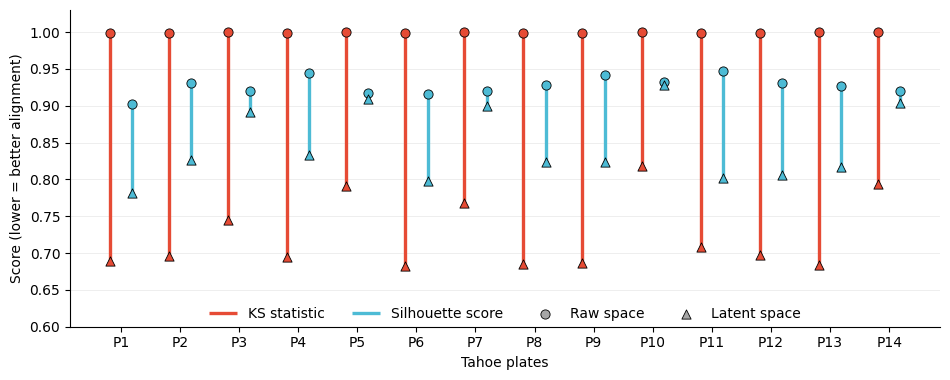

In [2]:
from scipy.stats import ks_2samp
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


def ks_mean(A, B):
    return float(np.mean([ks_2samp(A[:, j], B[:, j])[0] for j in range(A.shape[1])]))


def sil(A, B):
    M = np.concatenate([A, B])
    lab = np.array([0] * len(A) + [1] * len(B))
    return float(silhouette_score(M, lab, metric='cosine'))


rows = []
for p in range(1, 15):
    TX_p, _ = load(TAHOE_PATH % p, p, cap=N_TAHOE_CAP)
    TZ_p = encode(TX_p, graph_of(TAHOE_PROC % p))
    rows.append({'plate': p,
                 'ks_raw': ks_mean(LX, TX_p), 'ks_latent': ks_mean(LZ, TZ_p),
                 'sil_raw': sil(LX, TX_p), 'sil_latent': sil(LZ, TZ_p)})
    print('P%-2d  KS %.4f -> %.4f   silhouette %.4f -> %.4f'
          % (p, rows[-1]['ks_raw'], rows[-1]['ks_latent'],
             rows[-1]['sil_raw'], rows[-1]['sil_latent']), flush=True)

print('means  KS %.4f -> %.4f   silhouette %.4f -> %.4f'
      % (np.mean([r['ks_raw'] for r in rows]), np.mean([r['ks_latent'] for r in rows]),
         np.mean([r['sil_raw'] for r in rows]), np.mean([r['sil_latent'] for r in rows])))

x = np.arange(len(rows))
OFF = 0.19
fig, ax = plt.subplots(figsize=(9.6, 3.9))
for dx, kr, kl, color, name in ((-OFF, 'ks_raw', 'ks_latent', '#E64B35', 'KS statistic'),
                                (+OFF, 'sil_raw', 'sil_latent', '#4DBBD5',
                                 'Silhouette score')):
    hi = np.array([r[kr] for r in rows])
    lo = np.array([r[kl] for r in rows])
    ax.vlines(x + dx, lo, hi, color=color, lw=2.4, zorder=1, label=name)
    ax.scatter(x + dx, hi, s=44, facecolor=color, edgecolor='black', lw=0.6, zorder=2)
    ax.scatter(x + dx, lo, s=44, marker='^', facecolor=color, edgecolor='black',
               lw=0.6, zorder=2)
ax.scatter([], [], s=44, facecolor='0.65', edgecolor='black', lw=0.6, label='Raw space')
ax.scatter([], [], s=44, marker='^', facecolor='0.65', edgecolor='black', lw=0.6,
           label='Latent space')
ax.set_xticks(x); ax.set_xticklabels(['P%d' % r['plate'] for r in rows])
ax.set_xlabel('Tahoe plates')
ax.set_ylabel('Score (lower = better alignment)')
ax.legend(frameon=False, ncol=4, fontsize=10, loc='lower center',
          bbox_to_anchor=(0.5, -0.02))
ax.set_ylim(0.60, 1.03)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, lw=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


## The same two spaces drawn with UMAP

The top row is the raw 965-gene space and the bottom row the latent space, each coloured
three ways: by dataset, by Mini Tahoe cell line, and by perturbation state. LINCS is drawn
in grey in the second and third columns so the Mini Tahoe structure reads against it.

The cells are pooled over all fourteen plates so that every cell line appears, matching
the composition of the published supplementary figure.


UMAP input: 1200 LINCS, 2394 Mini-Tahoe, 15 cell lines


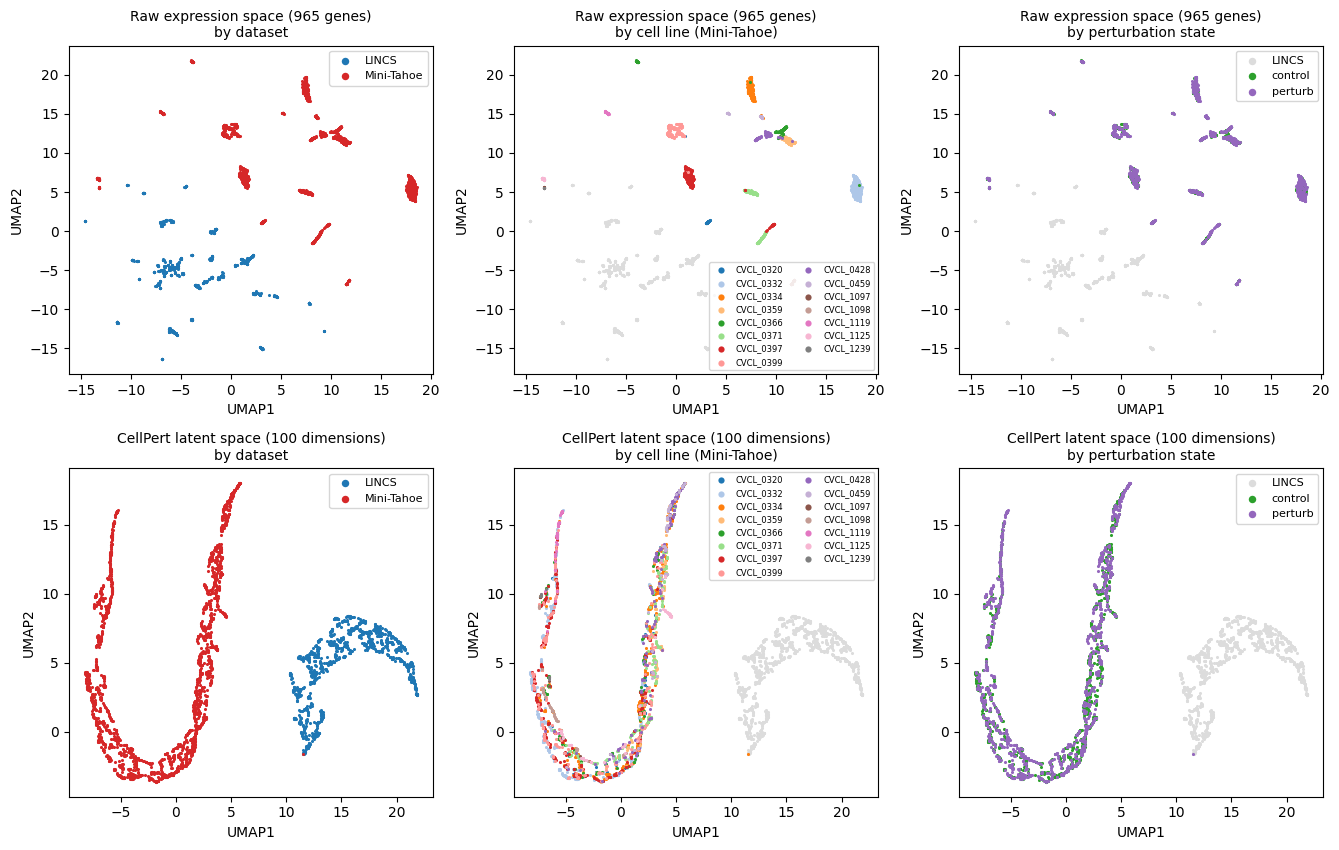

In [3]:
import umap
import matplotlib.pyplot as plt

# Same composition as the published supplementary figure: 1200 LINCS cells and 2400
# Mini Tahoe cells pooled over all fourteen plates, which is what puts all fifteen cell
# lines into the picture. The plate-by-plate section above uses far more cells; here the
# count is kept low so the scatter stays readable.
N_LINCS_UMAP, N_TAHOE_UMAP = 1200, 2400
per_plate = N_TAHOE_UMAP // 14

TXu, TZu_parts, cell_line, condition = [], [], [], []
for p in range(1, 15):
    Xp, obs = load(TAHOE_PATH % p, 100 + p, cap=per_plate)
    TXu.append(Xp)
    TZu_parts.append(encode(Xp, graph_of(TAHOE_PROC % p)))
    cell_line += list(obs['cell_type'].astype(str).values)
    condition += list(obs['condition'].astype(str).values)
TXu = np.concatenate(TXu)
cell_line = np.array(cell_line)
condition = np.array(condition)
TZu = np.concatenate(TZu_parts)

rng = np.random.default_rng(0)
sel = rng.choice(len(LX), size=min(N_LINCS_UMAP, len(LX)), replace=False)
LXu = LX[sel]
LZu = encode(LXu, EI_LINCS)

n_l = len(LXu)
dataset_lab = np.array(['LINCS'] * n_l + ['Mini-Tahoe'] * len(TXu))
print('UMAP input: %d LINCS, %d Mini-Tahoe, %d cell lines'
      % (n_l, len(TXu), len(set(cell_line))))

emb = {}
for space, (A, B) in (('raw', (LXu, TXu)), ('latent', (LZu, TZu))):
    emb[space] = umap.UMAP(n_neighbors=15, min_dist=0.1,
                           random_state=0).fit_transform(np.concatenate([A, B]))

GREY = '#DCDCDC'
lines = sorted(set(cell_line))
line_color = {c: plt.get_cmap('tab20')(i % 20) for i, c in enumerate(lines)}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))
for row, space in enumerate(('raw', 'latent')):
    E = emb[space]
    title = ('Raw expression space (965 genes)' if space == 'raw'
             else 'CellPert latent space (100 dimensions)')

    ax = axes[row, 0]
    for k, c in (('LINCS', '#1F77B4'), ('Mini-Tahoe', '#D62728')):
        m = dataset_lab == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby dataset', fontsize=10)

    ax = axes[row, 1]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, zorder=1)
    for c in lines:
        m = np.zeros(len(E), bool); m[n_l:] = cell_line == c
        ax.scatter(E[m, 0], E[m, 1], s=5, color=line_color[c], linewidths=0,
                   label=c, zorder=2)
    ax.legend(fontsize=6, markerscale=2.0, frameon=True, ncol=2, loc='best')
    ax.set_title(title + '\nby cell line (Mini-Tahoe)', fontsize=10)

    ax = axes[row, 2]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, label='LINCS', zorder=1)
    for k, c in (('control', '#2CA02C'), ('perturb', '#9467BD')):
        m = np.zeros(len(E), bool); m[n_l:] = condition == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k, zorder=2)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby perturbation state', fontsize=10)

for ax in axes.ravel():
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
plt.tight_layout(); plt.show()
